In [42]:
import warnings
from pathlib import Path

import prism

from imagematerials.concepts import knowledge_graph
from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks
from imagematerials.util import (
    export_to_netcdf, import_from_netcdf, rebroadcast_prep_data,
    read_climate_policy_config, read_circular_economy_config
)
from imagematerials.vehicles import (
    preprocess
)

import matplotlib.pyplot as plt


In [43]:
base_dir = "../data/raw"
climate_policy_scenario_dir = Path(base_dir) / 'SSP2'
prep_fp = Path("prep_vema.nc")

In [44]:
def prepare_scenario_data(scenario_name):
    scenario_path = Path(base_dir) / 'circular_economy_scenarios' / scenario_name
    circular_economy_scenario_dirs = {scenario_name: scenario_path}

    warnings.simplefilter("ignore")
    climate_policy_config = read_climate_policy_config(climate_policy_scenario_dir)
    circular_economy_config = read_circular_economy_config(circular_economy_scenario_dirs)

    prep_data = preprocess(base_dir, climate_policy_config, circular_economy_config)

    share_coords = set()
    for cur_type in prep_data["shares"].Type.values:
        share_coords.add(cur_type.split(" - ")[0])

    output_coords_type = [x for x in prep_data["stocks"].Type.values if x not in share_coords]
    output_coords_type += list(prep_data["shares"].coords["Type"].values)

    prep_data.pop("shares")

    new_prep_data = rebroadcast_prep_data(prep_data, knowledge_graph, dim="Type", output_coords=output_coords_type)
    new_prep_data = rebroadcast_prep_data(new_prep_data, knowledge_graph, dim="Region", output_coords=prep_data["stocks"].coords["Region"].values)
    new_prep_data["knowledge_graph"] = knowledge_graph
    new_prep_data["weights"] = new_prep_data.pop("vehicle_weights")

    return new_prep_data

In [45]:
from imagematerials.vehicles.modelling_functions import interpolate
import pandas as pd

lifetimes_vehicles: pd.DataFrame = pd.read_csv("../data/raw/vehicles/SSP2_CP/lifetimes_years.csv", index_col=[
        0, 1])


lifetimes_vehicles = lifetimes_vehicles.rename_axis('mode', axis=1).stack()
lifetimes_vehicles = lifetimes_vehicles[(lifetimes_vehicles.T != 0)]
lifetimes_vehicles = lifetimes_vehicles.unstack(['mode', 'data'])
lifetimes_vehicles = interpolate(pd.DataFrame(lifetimes_vehicles))
lifetimes_vehicles

mode Passenger Planes Freight Planes Trains High Speed Trains Freight Trains  \
data             mean           mean   mean              mean           mean   
year                                                                           
1807             20.0           21.0   35.0              30.0           38.0   
1808             20.0           21.0   35.0              30.0           38.0   
1809             20.0           21.0   35.0              30.0           38.0   
1810             20.0           21.0   35.0              30.0           38.0   
1811             20.0           21.0   35.0              30.0           38.0   
...               ...            ...    ...               ...            ...   
2056             20.0           21.0   35.0              30.0           38.0   
2057             20.0           21.0   35.0              30.0           38.0   
2058             20.0           21.0   35.0              30.0           38.0   
2059             20.0           21.0   35.0              30.0           38.0   
2060             20.0           21.0   35.0              30.0           38.0   

mode Small Ships Medium Ships Large Ships Very Large Ships  \
data        mean         mean        mean             mean   
year                                                         
1807        26.0         26.0        26.0             26.0   
1808        26.0         26.0        26.0             26.0   
1809        26.0         26.0        26.0             26.0   
1810        26.0         26.0        26.0             26.0   
1811        26.0         26.0        26.0             26.0   
...          ...          ...         ...              ...   
2056        26.0         26.0        26.0             26.0   
2057        26.0         26.0        26.0             26.0   
2058        26.0         26.0        26.0             26.0   
2059        26.0         26.0        26.0             26.0   
2060        26.0         26.0        26.0             26.0   

mode Light Commercial Vehicles  ...        Medium Freight Trucks  \
data                      mean  ...  stdev                 stdev   
year                            ...                                
1807                      14.0  ...  0.196                 0.266   
1808                      14.0  ...  0.196                 0.266   
1809                      14.0  ...  0.196                 0.266   
1810                      14.0  ...  0.196                 0.266   
1811                      14.0  ...  0.196                 0.266   
...                        ...  ...    ...                   ...   
2056                      14.0  ...  0.196                 0.266   
2057                      14.0  ...  0.196                 0.266   
2058                      14.0  ...  0.196                 0.266   
2059                      14.0  ...  0.196                 0.266   
2060                      14.0  ...  0.196                 0.266   

mode Heavy Freight Trucks Midi Buses Regular Buses Inland Ships  Bikes  Cars  \
data                stdev      stdev         stdev        stdev  stdev stdev   
year                                                                           
1807                0.266      0.322         0.322        0.266  0.266   0.4   
1808                0.266      0.322         0.322        0.266  0.266   0.4   
1809                0.266      0.322         0.322        0.266  0.266   0.4   
1810                0.266      0.322         0.322        0.266  0.266   0.4   
1811                0.266      0.322         0.322        0.266  0.266   0.4   
...                   ...        ...           ...          ...    ...   ...   
2056                0.266      0.322         0.322        0.266  0.266   0.4   
2057                0.266      0.322         0.322        0.266  0.266   0.4   
2058                0.266      0.322         0.322        0.266  0.266   0.4   
2059                0.266      0.322         0.322        0.266  0.266   0.4   
2060             

In [1]:
scenario_names = ["base","slow"]
scenario_results = {}

for scenario in scenario_names:
    print(f"Preparing data for scenario: {scenario}")
    data = prepare_scenario_data(scenario)
    scenario_results[scenario] = data

Preparing data for scenario: base


NameError: name 'prepare_scenario_data' is not defined

In [47]:
assert(scenario_results["slow"]["lifetimes"]["weibull"] == scenario_results["base"]["lifetimes"]["weibull"]).all().all()

AssertionError: 

Differences found in lifetime!


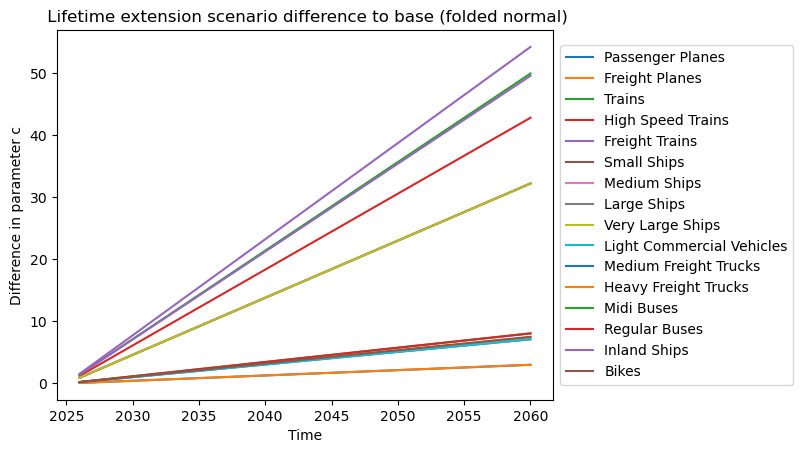

In [ ]:
# Safe way to check for full equality
slow_lifetime = scenario_results["slow"]["lifetimes"]["folded_norm"]
base_lifetime = scenario_results["base"]["lifetimes"]["folded_norm"]
diff_mask = slow_lifetime != base_lifetime
differences = diff_mask.where(diff_mask, drop=True)
# Coordinates where differences occur
coords_where_diff = differences.coords

# Get differing values from each scenario
slow_diff_vals = slow_lifetime.where(diff_mask, drop=True)
base_diff_vals = base_lifetime.where(diff_mask, drop=True)

# Create a combined dataset for easy comparison
import xarray as xr

comparison = xr.Dataset({
    "slow": slow_diff_vals,
    "base": base_diff_vals
})
if diff_mask.any().item():
    print("Differences found in lifetime!")
comparison
 
diff_life = slow_diff_vals - base_diff_vals
diff_life = diff_life.sel(ScipyParam = "c").to_pandas()
ax = diff_life.plot.line()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel("Difference in parameter c")
ax.set_xlabel("Time")
plt.title(" Lifetime extension scenario difference to base (folded normal)")
plt.show()

In [ ]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [ ]:
Region = list(scenario_results["base"]["stocks"].coords["Region"].values)
Time = [t for t in complete_timeline]
Cohort = Time
Type = list(scenario_results["base"]["stocks"].coords["Type"].values)
material = list(scenario_results["base"]["material_fractions"].coords["material"].values)

In [ ]:
main_model_factory_base = ModelFactory(
    scenario_results["base"], complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

main_model_factory_slow = ModelFactory(
    scenario_results["slow"], complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [ ]:
warnings.filterwarnings("ignore")
main_model_factory_base.simulate(simulation_timeline)
main_model_factory_slow.simulate(simulation_timeline)

In [ ]:
# Define consistent colors
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

In [59]:
production_base = main_model_factory_base.inflow_materials.to_array()
maintenance_base = main_model_factory_base.inflow_maintenance.to_array()
stock_base = main_model_factory_base.stock_by_cohort

production_slow = main_model_factory_slow.inflow_materials.to_array()
maintenance_slow = main_model_factory_slow.inflow_maintenance.to_array()
stock_slow = main_model_factory_slow.stock_by_cohort

target_types = [
"Cars",
 "High Speed Trains",
 "Passenger Planes",
 "Freight Planes",
 "Trucks",
 "Trains"
]

production_base = knowledge_graph.rebroadcast_xarray(production_base, output_coords=target_types, dim="Type")
maintenance_base = knowledge_graph.rebroadcast_xarray(maintenance_base, output_coords=target_types, dim="Type")
production_slow = knowledge_graph.rebroadcast_xarray(production_slow, output_coords=target_types, dim="Type")
maintenance_slow = knowledge_graph.rebroadcast_xarray(maintenance_slow, output_coords=target_types, dim="Type")
stock_base = knowledge_graph.rebroadcast_xarray(stock_base, output_coords=target_types, dim="Type")
stock_slow = knowledge_graph.rebroadcast_xarray(stock_slow, output_coords=target_types, dim="Type")

                      share                    
stat                   mean       min       max
Type                                           
High Speed Trains  1.004417  0.000000  1.917618
Passenger Planes        NaN  0.000000  0.000000
Freight Planes          NaN  0.000000  0.000000
Trucks             0.389209  0.290214  0.506551
Trains             0.372732  0.161906  0.626060


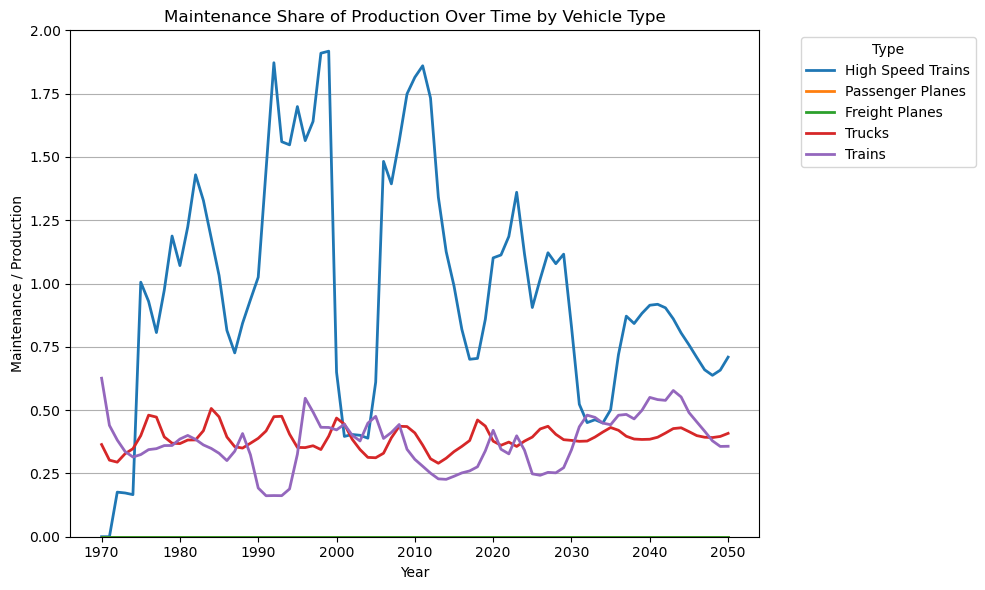

In [ ]:
# 1. Sum over materials and regions → get total kg per type per year
prod_total = production_base.sum(dim=["material", "Region"])  # dims: time x Type

prod_total = prod_total.rolling(time=5, center=True).mean()
maint_total = maintenance_base.sum(dim=["material", "Region"])  # dims: time x Type

# 2. Avoid divide-by-zero (just in case)
with xr.set_options(keep_attrs=True):
    share = maint_total / prod_total.where(prod_total > 0)  # dims: time x Type
share_filtered = share.sel(time=slice(1970, 2050))

# 3. Calculate mean and range over time
mean_share = share_filtered.where(share_filtered != 0).mean(dim="time")     # dims: Type
min_share = share_filtered.min(dim="time")       # dims: Type
max_share = share_filtered.max(dim="time")       # dims: Type

share_stats_df = xr.concat(
    [mean_share, min_share, max_share],
    dim="stat"
).assign_coords(stat=["mean", "min", "max"]).to_dataframe("share").unstack("stat")

# Result: A DataFrame with Type as index and columns: share['mean'], share['min'], share['max']
print(share_stats_df)

# 3. Plot share over time per Type
fig, ax = plt.subplots(figsize=(10, 6))

types = share_filtered["Type"].values
for t in types:
    ax.plot(
        share_filtered["time"],
        share_filtered.sel(Type=t),
        label=str(t),
        linewidth=2
    )

# 4. Formatting
ax.set_title("Maintenance Share of Production Over Time by Vehicle Type")
ax.set_ylabel("Maintenance / Production")
ax.set_xlabel("Year")
ax.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', zorder=0)
ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()


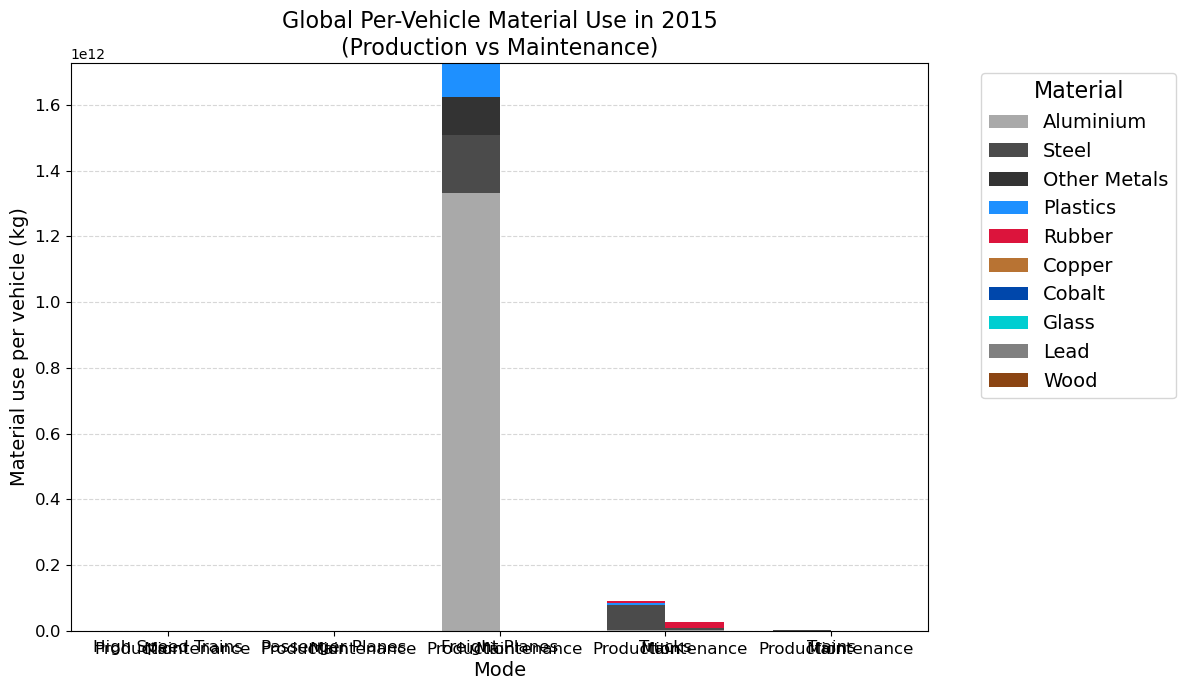

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Select 2015
prod_2015 = production_base.sel(time=2015)
maint_2015 = maintenance_base.sel(time=2015)

# Step 2: Sum over 'Region'
prod_sum = prod_2015.sum(dim="Region")  # dims left: Type x material
maint_sum = maint_2015.sum(dim="Region")

# 1. Group Rare Earths
rare_earths = ["Nd", "Mn", "Ni", "Ti", "Li"]

# Sum over the rare earths → new DataArrays
prod_rare = prod_sum.sel(material=rare_earths).sum(dim="material")
maint_rare = maint_sum.sel(material=rare_earths).sum(dim="material")

# Add "Other Rare Earths" to each sum
prod_sum = xr.concat(
    [prod_sum.drop_sel(material=rare_earths), prod_rare.expand_dims(material=["Other Metals"])],
    dim="material"
)
maint_sum = xr.concat(
    [maint_sum.drop_sel(material=rare_earths), maint_rare.expand_dims(material=["Other Metals"])],
    dim="material"
)

# 2. Rename materials using the rename_map
rename_map = {"Pb": "Lead", "Co": "Cobalt", "Cu": "Copper"}

# Rename materials in the 'material' coordinate
material_values = prod_sum["material"].values
new_material_values = [rename_map.get(str(m), str(m)) for m in material_values]

prod_sum = prod_sum.assign_coords(material=new_material_values)
maint_sum = maint_sum.assign_coords(material=new_material_values)

total_by_material = (prod_sum + maint_sum).sum(dim="Type")
sorted_materials = total_by_material.sortby(total_by_material, ascending=False)["material"].values

# Plot setup
types = prod_sum["Type"].values
x = np.arange(len(types))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bottom_prod = np.zeros(len(types))
bottom_maint = np.zeros(len(types))

# Plot each material in sorted order
for mat in sorted_materials:
    mat_prod = prod_sum.sel(material=mat).values
    mat_maint = maint_sum.sel(material=mat).values
    color = material_colors.get(str(mat), '#333333')

    # Plot bars with material label once (only for production bar, for legend)
    ax.bar(x - bar_width/2, mat_prod, bar_width, bottom=bottom_prod, label=str(mat), color=color)
    ax.bar(x + bar_width/2, mat_maint, bar_width, bottom=bottom_maint, color=color)

    bottom_prod += mat_prod
    bottom_maint += mat_maint

# Grid formatting
ax.set_axisbelow(True)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# X-axis labels and positions
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in types])

# Add subtitles under bars
for i, xpos in enumerate(x):
    ax.text(xpos - bar_width/2, -0.02 * max(bottom_prod.max(), bottom_maint.max()), 'Production',
            ha='center', va='top', fontsize=12)
    ax.text(xpos + bar_width/2, -0.02 * max(bottom_prod.max(), bottom_maint.max()), 'Maintenance',
            ha='center', va='top', fontsize=12)

# Axes and legend
ax.set_ylabel("Material use per vehicle (kg)", fontsize=14)
ax.set_title("Global Per-Vehicle Material Use in 2015\n(Production vs Maintenance)",fontsize=16)
ax.legend(title="Material", bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14, title_fontsize=16)

ax.set_xlabel("Mode", fontsize=14)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()



In [ ]:
production_base_aligned, production_slow_aligned = xr.align(production_base, production_slow, join="exact")
production_base_aligned = production_base_aligned.sel(material="Steel").sum(dim=["Region"])
production_slow_aligned = production_slow_aligned.sel(material="Steel").sum(dim=["Region"])

tolerance = 1e-12  # adjust as needed
prod_diff_mask = abs(production_base_aligned - production_slow_aligned) > tolerance


# Get differing values from each scenario
prod_slow_diff_vals = production_slow_aligned.where(prod_diff_mask, drop=True)
Prod_base_diff_vals = production_base_aligned.where(prod_diff_mask, drop=True)

prod_comparison = xr.Dataset({
    "slow": prod_slow_diff_vals,
    "base": Prod_base_diff_vals
})

if prod_diff_mask.any():
    print("Differences found!")
    prod_comparison
else:
    print("No meaningful differences found.")


Differences found!


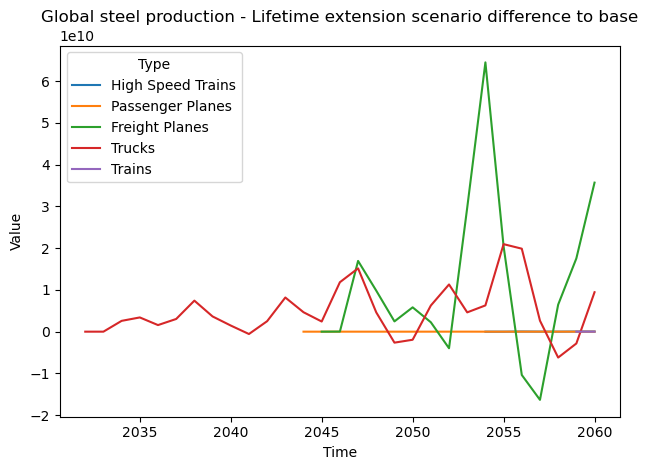

In [ ]:
difference = (Prod_base_diff_vals - prod_slow_diff_vals).to_pandas()

ax = difference.plot.line()
ax.set_ylabel("Value")
ax.set_xlabel("Time")
plt.title("Global steel production - Lifetime extension scenario difference to base")
plt.tight_layout()
plt.show()

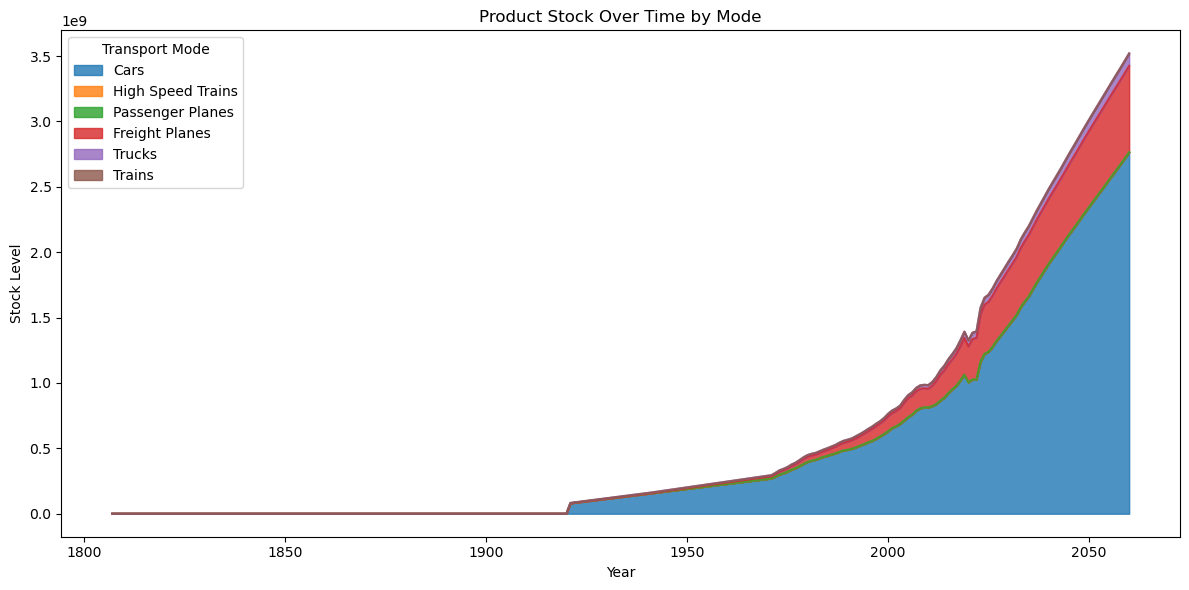

In [60]:
df = stock_base.sum(dim="Region").sum(dim="Cohort").to_pandas()
df.plot.area(figsize=(12, 6), alpha=0.8)
plt.title('Product Stock Over Time by Mode')
plt.xlabel('Year')
plt.ylabel('Stock Level')
plt.legend(title='Transport Mode', loc='upper left')
plt.tight_layout()
plt.show()


In [61]:
stock_base.sum(dim="Region").sum(dim="Cohort").sel(Time=2000)

<xarray.DataArray (Type: 6)> Size: 48B
array([6.29754325e+08, 7.72433844e+03, 1.76996691e+04, 1.14629323e+08,
       1.93585054e+07, 9.02385817e+04])
Coordinates:
    Time     int64 8B 2000
  * Type     (Type) <U17 408B 'Cars' 'High Speed Trains' ... 'Trucks' 'Trains'

In [ ]:
ax = stock_base.sum(dim="Region").sum(dim="Cohort").to_pandas()
.area(ax=ax, stacked=True, alpha=0.85, linewidth=0)
ax.set_ylabel("Value")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'area'

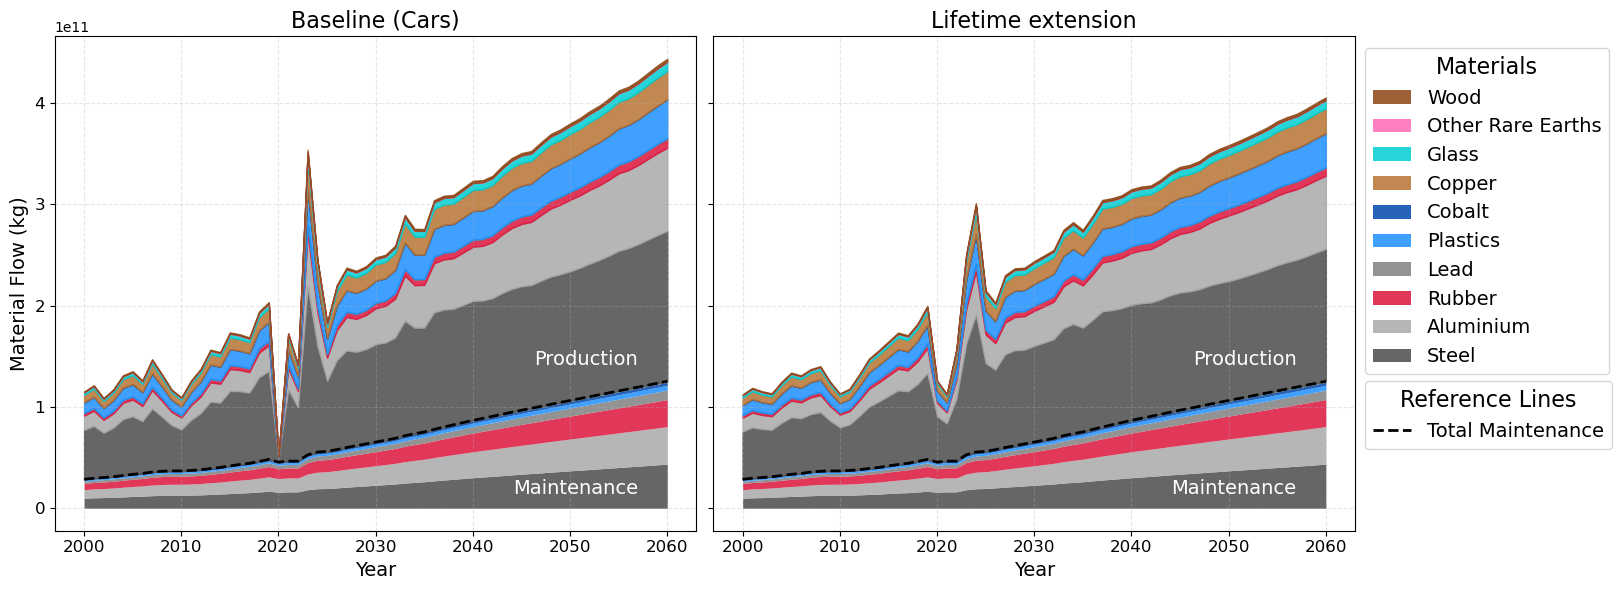

In [ ]:
import matplotlib.pyplot as plt


# Helper function to sort columns by total sum
def sort_columns_by_sum(df):
    return df.loc[:, df.sum(axis=0).sort_values(ascending=False).index]

# Helper function for a single train type plot
def plot_material_flow(ax, maint_df, prod_df, title, colors):
    # Filter from 1972
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]

    maint_df = sort_columns_by_sum(maint_df)
    prod_df = sort_columns_by_sum(prod_df)
    
    # Keep only non-zero materials across both
    valid_materials = (
        (maint_df != 0).any(axis=0) |
        (prod_df != 0).any(axis=0)
    )
    maint_df = maint_df.loc[:, valid_materials]
    prod_df = prod_df.loc[:, valid_materials]

    # Consistent material order and colors
    materials = maint_df.columns

    # Plot maintenance
    maint_df.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)
    ax.get_legend().remove()
    maintenance_total = maint_df.sum(axis=1)
    ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

    # Plot production stacked above maintenance
    prod_bottom = maintenance_total.copy()
    for mat in materials:
        top = prod_bottom + prod_df[mat]
        ax.fill_between(
            prod_df.index,
            prod_bottom,
            top,
            #label=f"Production: {mat}",
            color=colors.get(mat, "#999999"),
            alpha=0.85,
            #step="mid"
        )
        prod_bottom = top

    # Styling
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Year", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(visible=True, linestyle="--", alpha=0.3)

        # Add 'maintenance' label in bottom right (white)
    ax.text(
        maint_df.index[-1] - 3,                # rightmost year
        ax.get_ylim()[0] + 0.07 * ax.get_ylim()[1],  # just above bottom
        "Maintenance",
        color="white", fontsize=14, ha="right", va="bottom"
    )

    # Add 'maintenance' label just above the dashed line (black)
    ax.text(
        maint_df.index[-1] - 3,
        maintenance_total.iloc[-1] * 1.1,  # just above last value of line
        "Production",
        color="white", fontsize=14, ha="right", va="bottom"
    )


# === Load data ===
# Maintenance and production for both types
prod_df = production_base.sum(dim=["Region", "Type"]).to_pandas()

#prod_df = prod_df.rolling(window=2, center=True).mean()

maint_df = maintenance_base.sum(dim=["Region", "Type"]).to_pandas()

rare_earths = ["Nd", "Mn", "Ni", "Ti","Li"]
maint_df["Other Rare Earths"] = maint_df[rare_earths].sum(axis=1)
prod_df["Other Rare Earths"] = prod_df[rare_earths].sum(axis=1)
maint_df = maint_df.drop(columns=rare_earths, errors="ignore")
prod_df = prod_df.drop(columns=rare_earths, errors="ignore")

rename_map = {
    "Pb": "Lead",
    "Co": "Cobalt",
    "Cu": "Copper"
}
maint_df = maint_df.rename(columns=rename_map)
prod_df = prod_df.rename(columns=rename_map)

# Lifetime extension
prod_df_extension = production_slow.sum(dim=["Region", "Type"]).to_pandas()

prod_df_extension = prod_df_extension.rolling(window=2, center=True).mean()

maint_df_extension = maintenance_slow.sum(dim=["Region", "Type"]).to_pandas()

rare_earths = ["Nd", "Mn", "Ni", "Ti","Li"]
maint_df_extension["Other Rare Earths"] = maint_df_extension[rare_earths].sum(axis=1)
prod_df_extension["Other Rare Earths"] = prod_df_extension[rare_earths].sum(axis=1)
maint_df_extension = maint_df_extension.drop(columns=rare_earths, errors="ignore")
prod_df_extension = prod_df_extension.drop(columns=rare_earths, errors="ignore")

rename_map = {
    "Pb": "Lead",
    "Co": "Cobalt",
    "Cu": "Copper"
}
maint_df_extension = maint_df_extension.rename(columns=rename_map)
prod_df_extension = prod_df_extension.rename(columns=rename_map)

# === Create side-by-side plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_material_flow(axes[0], maint_df, prod_df, f"Baseline ({', '.join(sorted(target_types))})",material_colors)
plot_material_flow(axes[1], maint_df_extension, prod_df_extension, "Lifetime extension",material_colors)

# Shared Y label
axes[0].set_ylabel("Material Flow (kg)", fontsize=14)

# Get all handles
all_handles, all_labels = axes[1].get_legend_handles_labels()

# Separate Total Maintenance
material_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if not l.startswith("Total")]
maintenance_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if l.startswith("Total")]

# Shared legend (outside)
handles, labels = axes[1].get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]
material_handles_labels = list(zip(*material_handles_labels))
fig.legend(material_handles_labels[0][::-1], material_handles_labels[1][::-1],
           title="Materials", bbox_to_anchor=(0.85, 0.64), loc="center left", fontsize=14, title_fontsize=16)

# Total line legend
if maintenance_handles_labels:
    mh, ml = zip(*maintenance_handles_labels)
    fig.legend(mh, ml, title="Reference Lines", bbox_to_anchor=(0.85, 0.3), loc="center left", fontsize=14, title_fontsize=16)

# Layout optimization for slides
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load data ===

prod_by_type = production_base.sum(dim=["Region", "material"]).to_pandas()
maint_by_type = maintenance_base.sum(dim=["Region", "material"]).to_pandas()

prod_by_type = prod_by_type.rolling(window=2, center=True).mean()


type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
# Assign specific colors – feel free to tweak these
type_colors = {
    "Cars": "#aec7e8",              # light blue (less intense than #1f77b4)
    "Buses": "#ffbb78",             # lighter orange (less harsh)
    "Trains": "#e31a1c",            # vivid red (more intense than #d62728)
    "High Speed Trains": "#9900ff", # electric purple (very striking)
    "Trucks": "#c7b8a3",            # muted taupe/light brown (less intense)
}

# Optional: check that all target_types are covered
missing = [t for t in target_types if t not in type_colors]
if missing:
    print(f"Missing color assignments for: {missing}")
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
maint_by_type.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)

# Plot total maintenance as dashed black line
maintenance_total = maint_by_type.sum(axis=1)
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

# Plot production stacked above maintenance
prod_bottom = maintenance_total.copy()
for t in target_types:
    top = prod_bottom + prod_by_type[t]
    ax.fill_between(
        prod_by_type.index,
        prod_bottom,
        top,
        color=type_colors.get(t, "#999999"),
        alpha=0.85
    )
    prod_bottom = top

# Styling
ax.set_title("Production and Maintenance by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Material Flow (kg)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()

In [ ]:
# === Create side-by-side plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_material_flow(axes[0], maint_df, prod_df, f"Baseline by material ({', '.join(sorted(target_types))})",material_colors)
plot_material_flow(axes[1], maint_by_type, prod_by_type, "Baseline by vehicle type",type_colors)

# Shared Y label
axes[0].set_ylabel("Material Flow (kg)", fontsize=14)

# === Draw once to make sure handles have correct styles ===
fig.canvas.draw()

# --- Collect handles/labels ---

# Left axis: materials
mat_handles, mat_labels = axes[0].get_legend_handles_labels()
seen = set()
mat_legend = [(h, l) for h, l in zip(mat_handles, mat_labels) if not l.startswith("Total")]

# Right axis: types and reference lines
right_handles, right_labels = axes[1].get_legend_handles_labels()
type_legend = [(h, l) for h, l in zip(right_handles, right_labels) if not l.startswith("Total")]
ref_legend = [(h, l) for h, l in zip(right_handles, right_labels) if l.startswith("Total")]

# Unzip
mat_h, mat_l = zip(*mat_legend) if mat_legend else ([], [])
type_h, type_l = zip(*type_legend) if type_legend else ([], [])
ref_h, ref_l = zip(*ref_legend) if ref_legend else ([], [])

# --- Add legends ---

# Materials legend
fig.legend(mat_h, mat_l, title="Materials",
           bbox_to_anchor=(0.78, 0.7), loc="center left",
           fontsize=13, title_fontsize=15)

# Vehicle types legend
fig.legend(type_h, type_l, title="Vehicle Types",
           bbox_to_anchor=(0.78, 0.3), loc="center left",
           fontsize=13, title_fontsize=15)

# Reference lines legend
if ref_h:
    fig.legend(ref_h, ref_l, title="Reference Lines",
               bbox_to_anchor=(0.78, 0.1), loc="center left",
               fontsize=13, title_fontsize=15)

# Final layout
plt.tight_layout()
plt.subplots_adjust(right=0.78)  # Adjust for all three legend boxes
plt.show()

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load data ===

prod_by_type = production_slow.sum(dim=["Region", "material"]).to_pandas()
maint_by_type = maintenance_slow.sum(dim=["Region", "material"]).to_pandas()


type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
type_colors = {t: mcolors.to_hex(type_cmap(i)) for i, t in enumerate(target_types)}
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
maint_by_type.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)

# Plot total maintenance as dashed black line
maintenance_total = maint_by_type.sum(axis=1)
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

# Plot production stacked above maintenance
prod_bottom = maintenance_total.copy()
for t in target_types:
    top = prod_bottom + prod_by_type[t]
    ax.fill_between(
        prod_by_type.index,
        prod_bottom,
        top,
        color=type_colors.get(t, "#999999"),
        alpha=0.85
    )
    prod_bottom = top

# Styling
ax.set_title("Production and Maintenance by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Material Flow (kg)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()